# Performance Analysis with Alphalens

## Imports & Settings

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns

from alphalens.tears import (
    create_summary_tear_sheet,
    create_full_tear_sheet,
)

from alphalens.utils import get_clean_factor_and_forward_returns

In [2]:
sns.set_style("whitegrid")

In [3]:
np.random.seed(42)
idx = pd.IndexSlice

In [4]:
results_path = Path("results", "asset_pricing")
if not results_path.exists():
    results_path.mkdir(parents=True)

## Alphalens Analysis

### Load predictions

In [5]:
DATA_STORE = Path(results_path / "data.h5")

In [6]:
predictions = pd.read_hdf(results_path / "predictions.h5", "predictions")

In [7]:
factor = (
    predictions.mean(axis=1)
    .unstack("ticker")
    .resample("W-FRI", level="date")
    .last()
    .stack()
    .tz_localize("UTC", level="date")
    .sort_index()
)
tickers = factor.index.get_level_values("ticker").unique()

In [8]:
factor

date                       ticker
2015-01-09 00:00:00+00:00  AAL      -0.017787
                           AAME     -0.047971
                           AAOI      0.019904
                           AAON     -0.020270
                           AAPL      0.029384
                                       ...   
2019-12-27 00:00:00+00:00  ZTEK      0.001614
                           ZUMZ     -0.007801
                           ZVRA     -0.007168
                           ZYME     -0.021160
                           ZYXI     -0.021109
Length: 432120, dtype: float32

### Get trade prices

In [9]:
def get_trade_prices(tickers):
    prices = pd.read_hdf(DATA_STORE, "stocks/prices/adjusted")
    prices.index.names = ["ticker", "date"]
    prices = prices.loc[idx[tickers, "2014":"2020"], "open"]
    return (
        prices.unstack("ticker")
        .sort_index()
        .shift(-1)
        .resample("W-FRI", level="date")
        .last()
        .tz_localize("UTC")
    )

In [10]:
trade_prices = get_trade_prices(tickers)

In [11]:
trade_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 314 entries, 2014-01-03 00:00:00+00:00 to 2020-01-03 00:00:00+00:00
Freq: W-FRI
Columns: 1662 entries, AAL to ZYXI
dtypes: float64(1662)
memory usage: 4.0 MB


In [ ]:
trade_prices.to_hdf("tmp.h5", key="trade_prices")

### Generate tearsheet input

In [14]:
factor_data = get_clean_factor_and_forward_returns(
    factor=factor, prices=trade_prices, quantiles=5, periods=(5, 10, 21)
).sort_index()
factor_data.info()

c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\alphalens\utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\alphalens\utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\alphalens\utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or sp

Dropped 25.0% entries from factor data: 25.0% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 323984 entries, (Timestamp('2015-01-09 00:00:00+0000', tz='UTC'), 'AAL') to (Timestamp('2019-08-09 00:00:00+0000', tz='UTC'), 'ZYXI')
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   5D               323984 non-null  float64
 1   10D              323984 non-null  float64
 2   21D              323984 non-null  float64
 3   factor           323984 non-null  float32
 4   factor_quantile  323984 non-null  int64  
dtypes: float32(1), float64(3), int64(1)
memory usage: 12.4+ MB


### Create Tearsheet

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-1.787114,0.007066,-0.072676,0.062793,64899,20.031545
2,-0.085841,0.026738,-0.024082,0.019593,64742,19.983086
3,-0.061395,0.040614,-0.000813,0.018276,64755,19.987098
4,-0.044166,0.078749,0.020661,0.019416,64742,19.983086
5,-0.018101,0.221077,0.054920,0.027482,64846,20.015186


Returns Analysis


,5D,10D,21D
Ann. alpha,-0.022,-0.015,-0.042
beta,-0.062,-0.078,-0.041
Mean Period Wise Return Top Quantile (bps),-15.501,-27.070,-25.827
Mean Period Wise Return Bottom Quantile (bps),11.968,-0.638,0.577
Mean Period Wise Spread (bps),-27.469,-26.043,-25.877


Information Analysis


,5D,10D,21D
IC Mean,0.012,0.014,0.018
IC Std.,0.068,0.056,0.053
Risk-Adjusted IC,0.170,0.249,0.343
t-stat(IC),2.638,3.861,5.312
p-value(IC),0.009,0.000,0.000
IC Skew,0.065,0.305,0.237
IC Kurtosis,0.442,0.208,-0.126


Turnover Analysis


,5D,10D,21D
Quantile 1 Mean Turnover,0.486,0.573,0.676
Quantile 2 Mean Turnover,0.700,0.738,0.781
Quantile 3 Mean Turnover,0.728,0.757,0.783
Quantile 4 Mean Turnover,0.696,0.735,0.768
Quantile 5 Mean Turnover,0.505,0.590,0.702


,5D,10D,21D
Mean Factor Rank Autocorrelation,0.572,0.438,0.25


<Figure size 640x480 with 0 Axes>

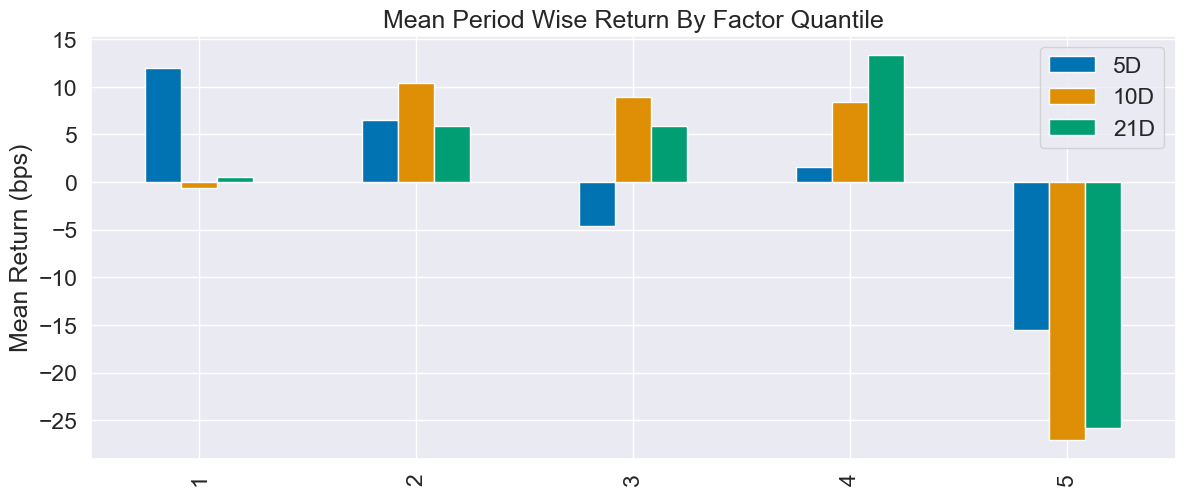

In [15]:
create_summary_tear_sheet(factor_data)

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-1.787114,0.007066,-0.072676,0.062793,64899,20.031545
2,-0.085841,0.026738,-0.024082,0.019593,64742,19.983086
3,-0.061395,0.040614,-0.000813,0.018276,64755,19.987098
4,-0.044166,0.078749,0.020661,0.019416,64742,19.983086
5,-0.018101,0.221077,0.054920,0.027482,64846,20.015186


Returns Analysis


,5D,10D,21D
Ann. alpha,-0.022,-0.015,-0.042
beta,-0.062,-0.078,-0.041
Mean Period Wise Return Top Quantile (bps),-15.501,-27.070,-25.827
Mean Period Wise Return Bottom Quantile (bps),11.968,-0.638,0.577
Mean Period Wise Spread (bps),-27.469,-26.043,-25.877


<Figure size 640x480 with 0 Axes>

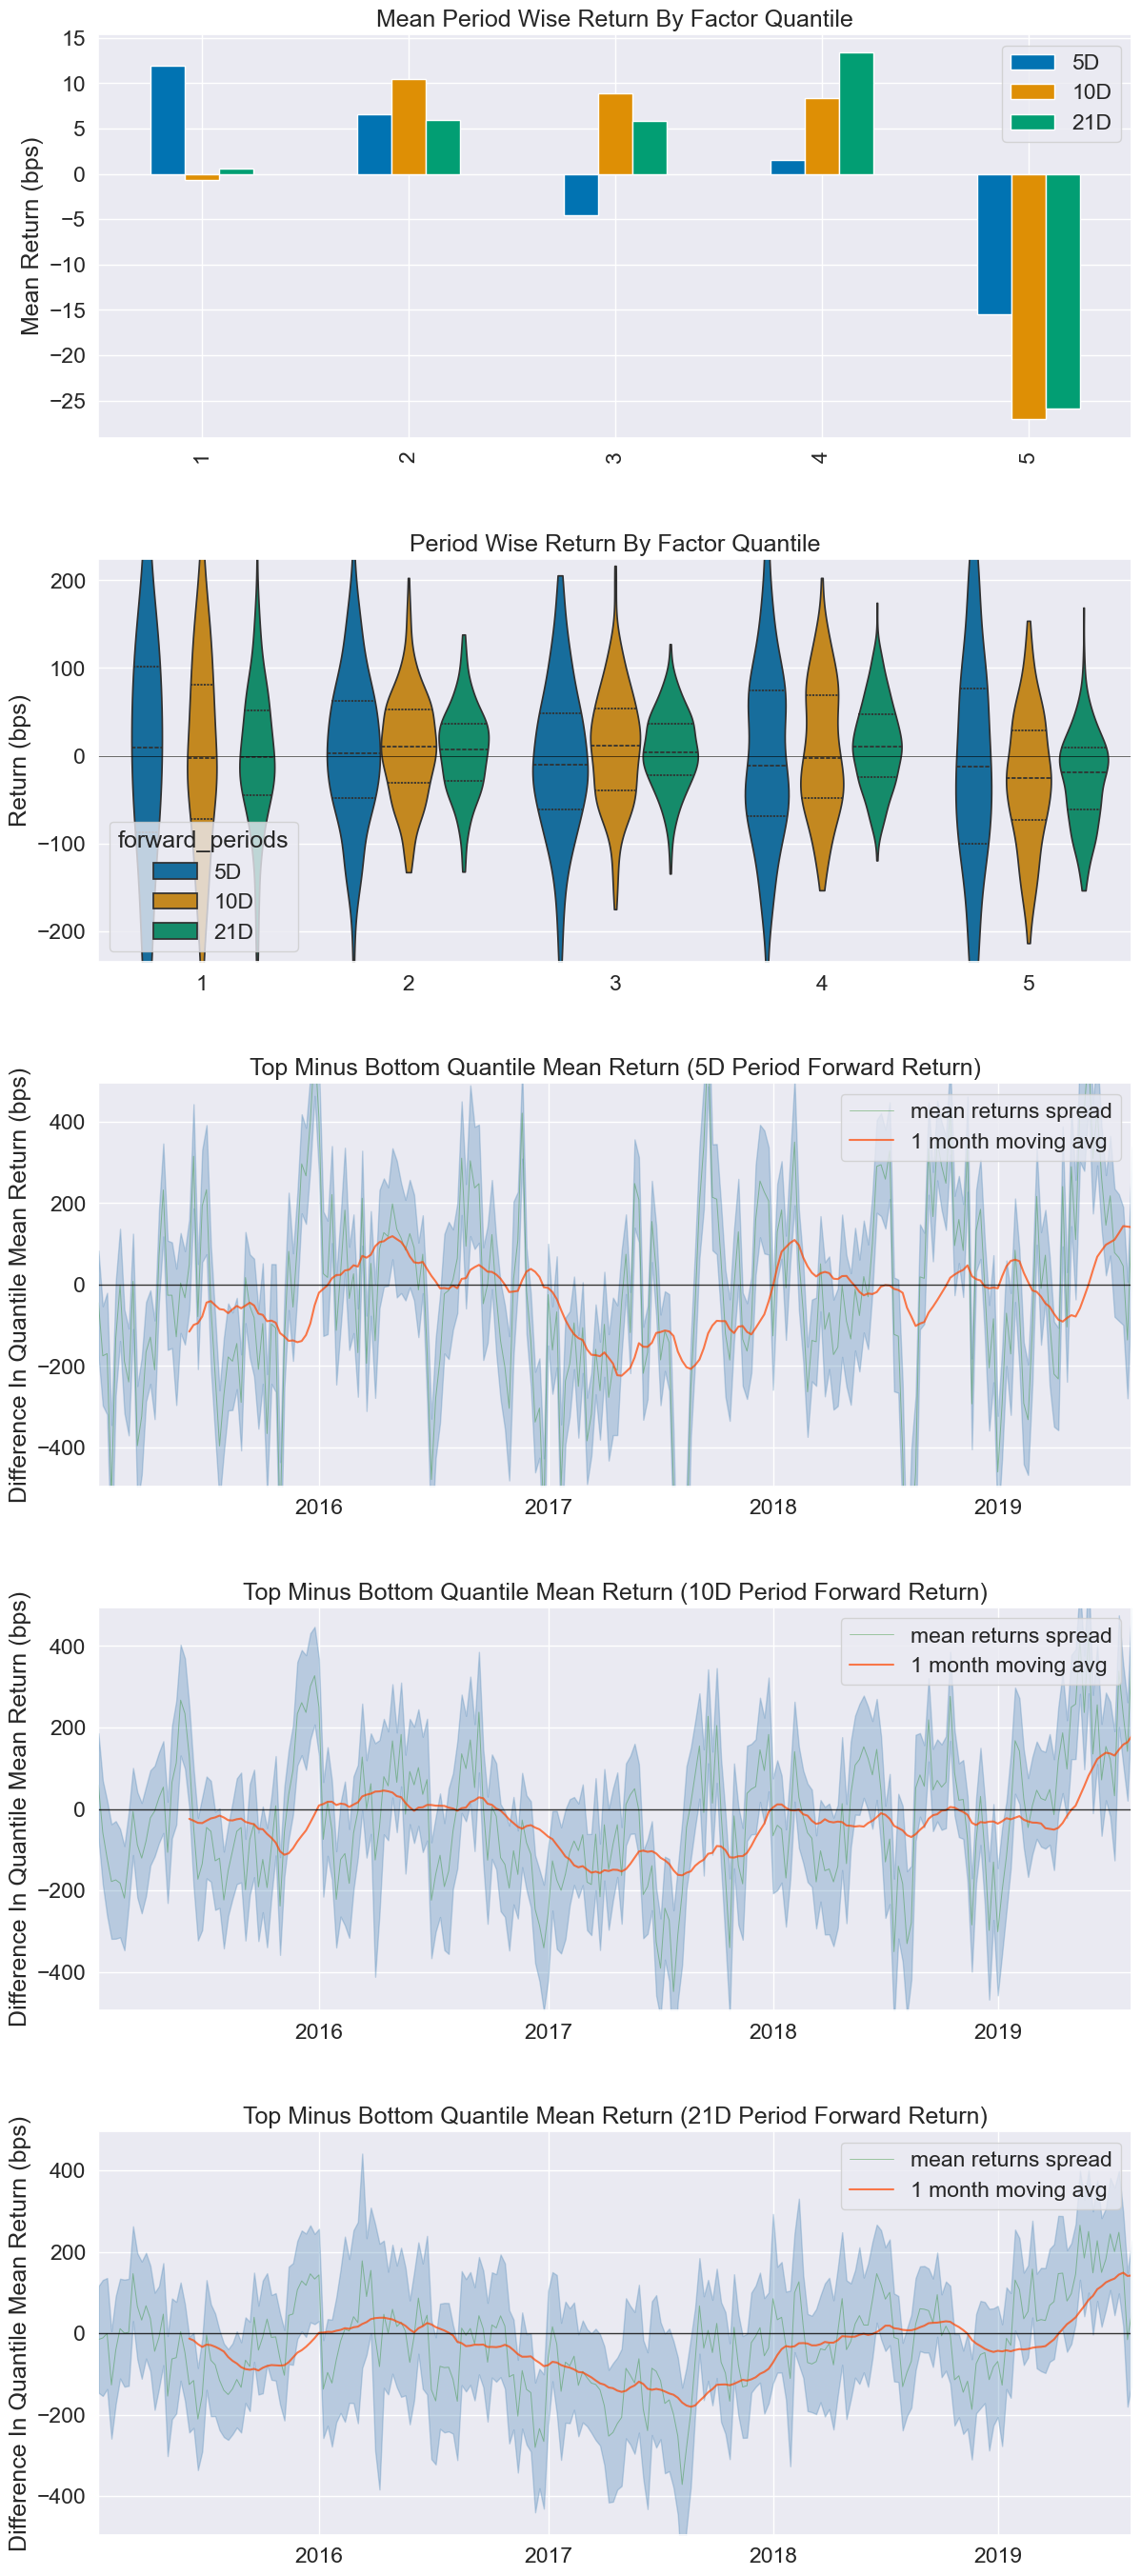

Information Analysis


,5D,10D,21D
IC Mean,0.012,0.014,0.018
IC Std.,0.068,0.056,0.053
Risk-Adjusted IC,0.170,0.249,0.343
t-stat(IC),2.638,3.861,5.312
p-value(IC),0.009,0.000,0.000
IC Skew,0.065,0.305,0.237
IC Kurtosis,0.442,0.208,-0.126


c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\alphalens\performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


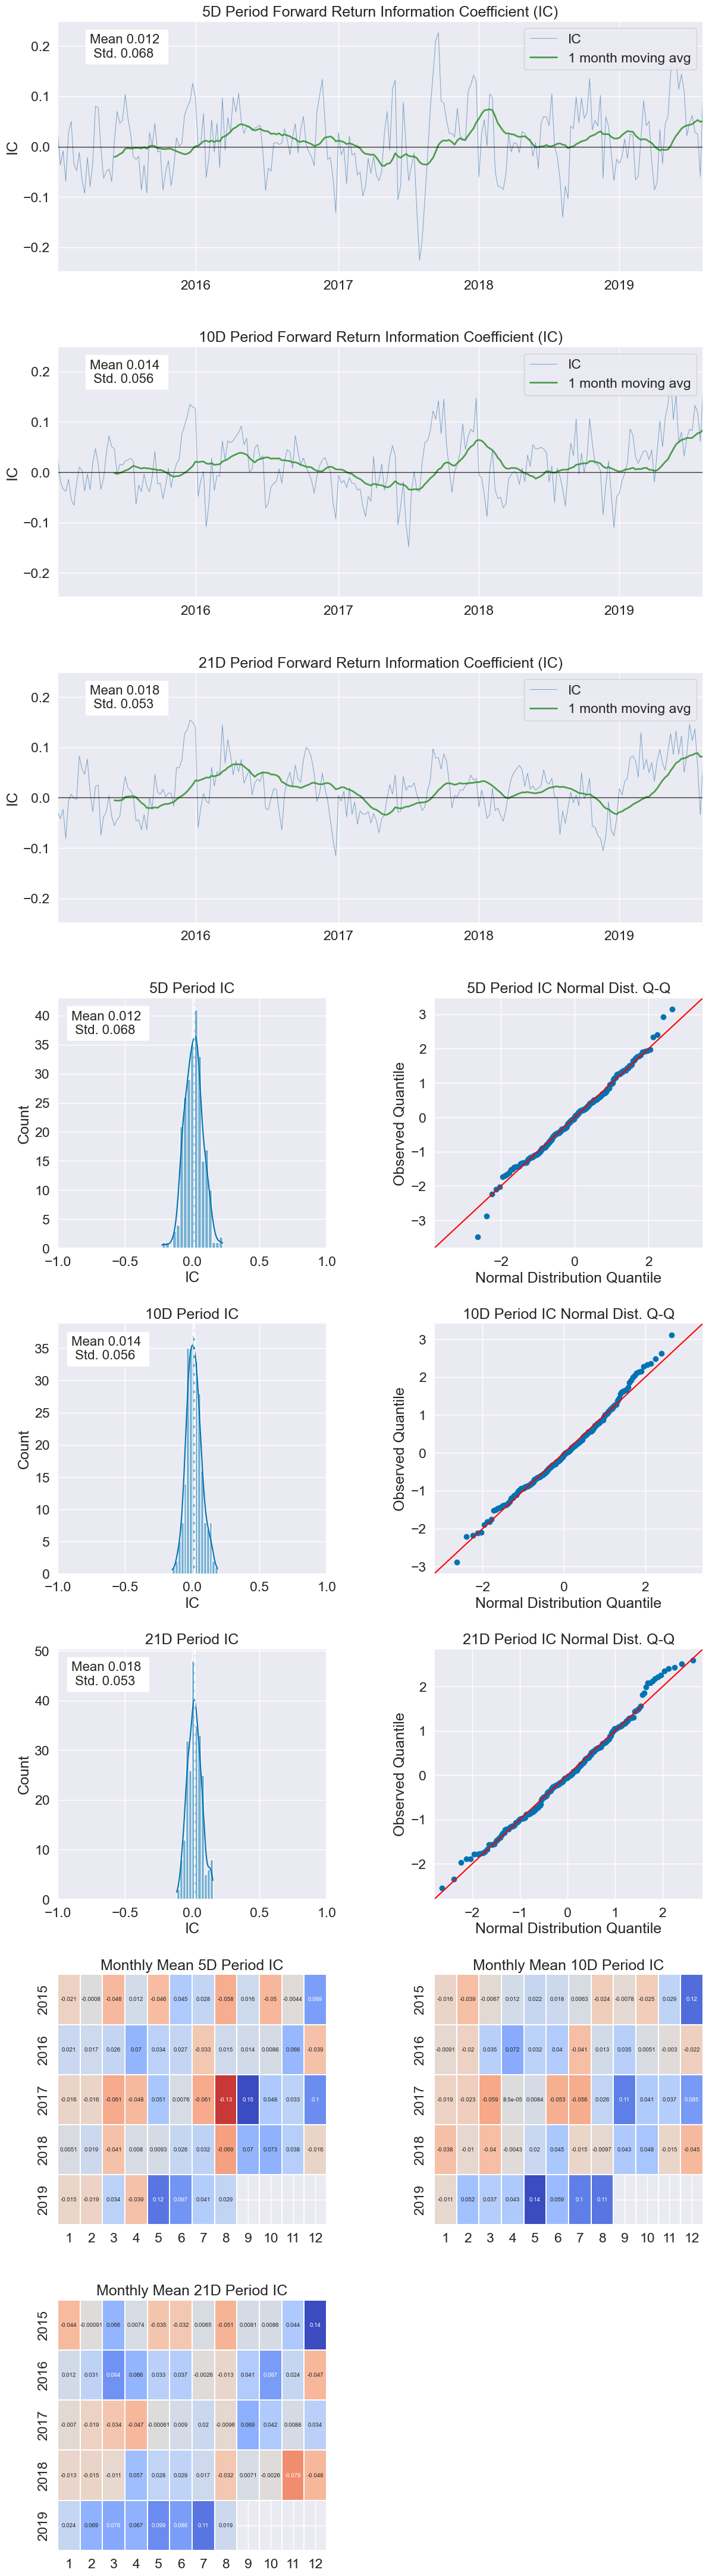

c:\Users\paxto\miniforge3\envs\ml4t\lib\site-packages\alphalens\utils.py:929: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,5D,10D,21D
Quantile 1 Mean Turnover,0.486,0.573,0.676
Quantile 2 Mean Turnover,0.700,0.738,0.781
Quantile 3 Mean Turnover,0.728,0.757,0.783
Quantile 4 Mean Turnover,0.696,0.735,0.768
Quantile 5 Mean Turnover,0.505,0.590,0.702


,5D,10D,21D
Mean Factor Rank Autocorrelation,0.572,0.438,0.25


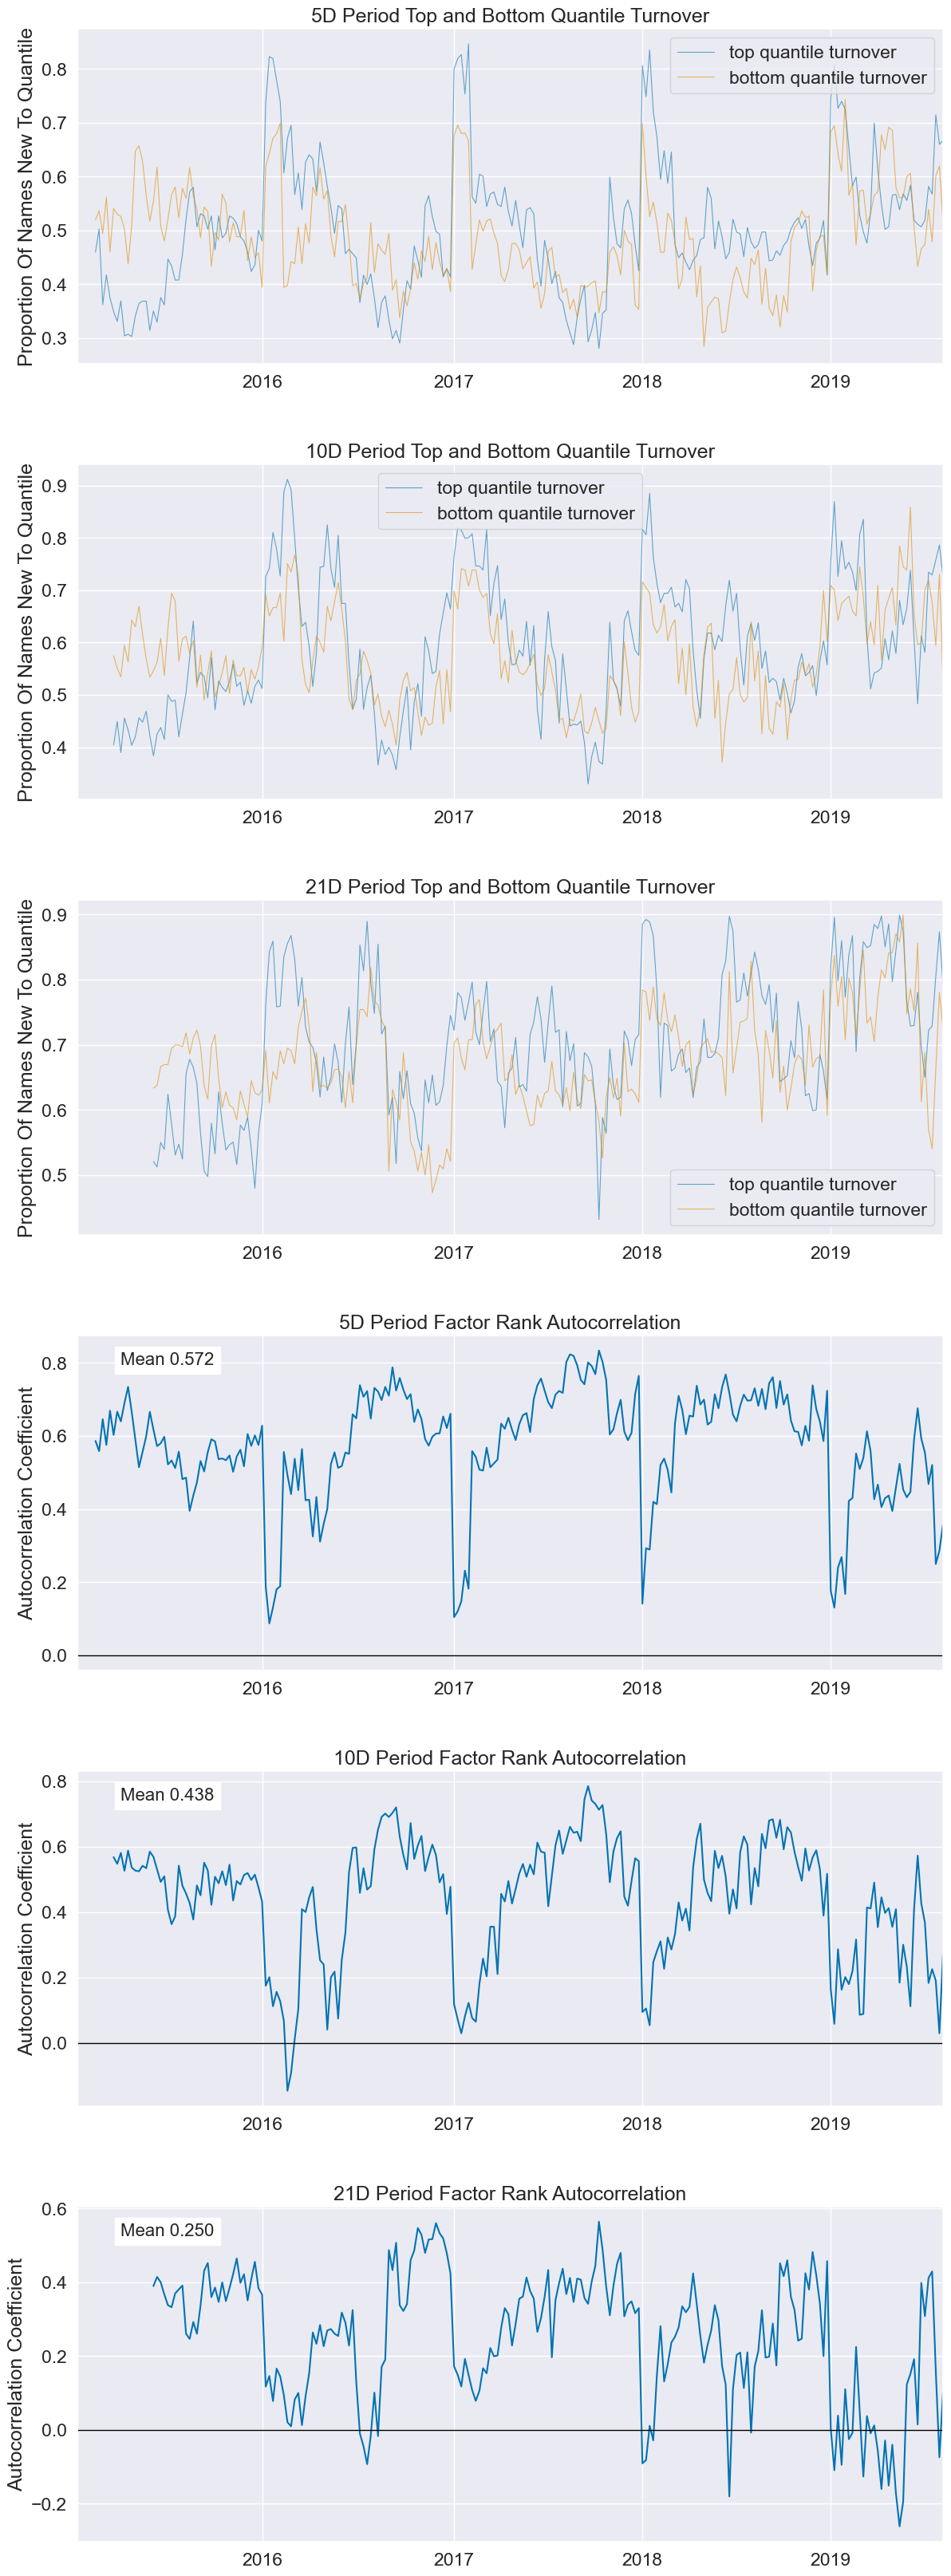

In [16]:
create_full_tear_sheet(factor_data)